In [1]:
# ============================================================
# OCR PIPELINE - COMPLETE SETUP
# ============================================================

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
import sys

# Create project directory
project_dir = '/content/drive/My Drive/OCR_Pipeline_Research'
os.makedirs(project_dir, exist_ok=True)
os.chdir(project_dir)

print(f"✓ Working directory: {os.getcwd()}")

# Create directory structure
dirs = [
    'data/images',
    'data/annotations',
    'src',
    'notebooks',
    'scripts',
    'results',
    'models'
]

for d in dirs:
    os.makedirs(d, exist_ok=True)

print(f"✓ Created directories: {', '.join(dirs)}")

Mounted at /content/drive
✓ Working directory: /content/drive/My Drive/OCR_Pipeline_Research
✓ Created directories: data/images, data/annotations, src, notebooks, scripts, results, models


In [9]:
print("Installing dependencies... (this takes ~3-5 minutes)")

# Core packages
!pip install -q opencv-python pillow numpy matplotlib pandas

# OCR models
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q transformers

# Optional OCR models for comparison
!pip install -q pytesseract easyocr

# Utilities
!pip install -q pyyaml editdistance requests tqdm
!pip install pdf2image
# For Tesseract (traditional OCR)
!apt-get update -qq && apt-get install -qq tesseract-ocr
!apt-get install -y poppler-utils
print("\n✓ All dependencies installed!")

Installing dependencies... (this takes ~3-5 minutes)
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  poppler-utils
0 upgraded, 1 newly installed, 0 to remove and 11 not upgraded.
Need to get 186 kB of archives.
After this operation, 697 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 poppler-utils amd64 22.02.0-2ubuntu0.12 [186 kB]
Fetched 186 kB in 1s (325 kB/s)
Selecting previously unselected package poppler-utils.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../poppler-utils_22.02.0-2ubuntu0.12_amd64.deb ...
Unpacking poppler-utils (22.02.0-2ubuntu0.12) ...
Setting up poppler-utils (22.02.0-2ubunt

In [43]:
from PIL import Image, ImageDraw, ImageFont, ImageFilter
import numpy as np
import random
import os

def create_synthetic_document(text, filename, degradation_level=1, output_dir='data/images'):
    os.makedirs(output_dir, exist_ok=True)

    width, height = 950, 750

    # ----------------------------
    # STEP 1: Paper texture (IMPORTANT)
    # ----------------------------
    base = np.ones((height, width, 3), dtype=np.uint8) * (240 - degradation_level * 10)

    noise = np.random.normal(0, 8 + degradation_level * 4, (height, width, 1))
    base = base + noise
    base = np.clip(base, 200, 255).astype(np.uint8)

    img = Image.fromarray(base, 'RGB')

    # ----------------------------
    # STEP 2: Uneven lighting (aging)
    # ----------------------------
    gradient = np.tile(np.linspace(0, 40 + degradation_level * 10, width), (height, 1))
    gradient = gradient.astype(np.uint8)

    gradient_img = Image.fromarray(gradient).convert("L")

    aged_color = (210, 190, 160)
    img = Image.composite(img, Image.new("RGB", (width, height), aged_color), gradient_img)

    draw = ImageDraw.Draw(img, 'RGBA')

    # ----------------------------
    # STEP 3: Font (serif = historical)
    # ----------------------------
    try:
        font = ImageFont.truetype(
            "/usr/share/fonts/truetype/dejavu/DejaVuSerif.ttf",
            30 - degradation_level * 2
        )
    except:
        font = ImageFont.load_default()

    # ----------------------------
    # STEP 4: Draw text (CHARACTER-WISE)
    # ----------------------------
    x, y = 60, 80

    for char in text:
        # jitter
        dx = random.randint(-2, 2)
        dy = random.randint(-2, 2)

        # ink variation
        ink = (
            random.randint(60, 120),
            random.randint(50, 90),
            random.randint(40, 80)
        )

        draw.text((x + dx, y + dy), char, fill=ink, font=font)

        # spacing
        x += font.getbbox(char)[2] + random.randint(0, 2)

    # ----------------------------
    # STEP 5: Stains / aging marks
    # ----------------------------
    for _ in range(degradation_level * 8 + random.randint(5, 10)):
        x = random.randint(0, width)
        y = random.randint(0, height)
        size = random.randint(10, 40)

        draw.ellipse(
            (x, y, x + size, y + size),
            fill=(120, 100, 80, random.randint(15, 60))
        )

    # ----------------------------
    # STEP 6: Scratches / lines
    # ----------------------------
    for _ in range(5 + degradation_level * 3):
        x1 = random.randint(0, width)
        x2 = x1 + random.randint(20, 150)
        y = random.randint(0, height)

        draw.line((x1, y, x2, y), fill=(150, 130, 100), width=1)

    # ----------------------------
    # STEP 7: Perspective distortion
    # ----------------------------
    if degradation_level >= 2:
        img = img.transform(
            (width, height),
            Image.PERSPECTIVE,
            [
                1, 0.01 * random.uniform(-1, 1), 0,
                0.01 * random.uniform(-1, 1), 1, 0,
                0.0005 * random.uniform(-1, 1),
                0.0005 * random.uniform(-1, 1)
            ],
        )

    # ----------------------------
    # STEP 8: Blur (scanner effect)
    # ----------------------------
    img = img.filter(ImageFilter.GaussianBlur(radius=0.5 + degradation_level * 0.5))

    # ----------------------------
    # STEP 9: Final noise layer
    # ----------------------------
    final_np = np.array(img)
    noise = np.random.normal(0, 5 + degradation_level * 2, final_np.shape)
    final_np = np.clip(final_np + noise, 0, 255).astype(np.uint8)

    img = Image.fromarray(final_np)

    # ----------------------------
    # STEP 10: Save
    # ----------------------------
    output_path = os.path.join(output_dir, filename)
    img.save(output_path)

    return output_path

In [10]:
"""
PDF EXTRACTION
If you upload a historical PDF, extract pages as images
"""

from pdf2image import convert_from_path
from pathlib import Path

def extract_pdf_pages(pdf_path, output_dir='data/images/pdf', max_pages=3):
    """Extract pages from PDF and save as PNG"""

    os.makedirs(output_dir, exist_ok=True)

    try:
        print(f"Extracting pages from: {pdf_path}")
        pages = convert_from_path(pdf_path, dpi=300, first_page=1, last_page=max_pages)

        for idx, page in enumerate(pages, 1):
            filename = f"pdf_{idx:02d}.png"
            output_path = os.path.join(output_dir, filename)
            page.save(output_path, 'PNG')
            print(f"✓ Saved: {filename} ({page.size})")

        return len(pages)

    except Exception as e:
        print(f"✗ Error: {e}")
        return 0


# Check for PDFs
pdf_files = list(Path('data/images/pdf').glob('*.pdf'))

if pdf_files:
    print(f"Found {len(pdf_files)} PDF(s)\n")
    for pdf in pdf_files:
        extract_pdf_pages(str(pdf), max_pages=3)
else:
    print("To add PDFs:")
    print("1. Upload to Google Drive")
    print("2. Place in project/data/")
    print("3. Re-run this cell")
    print("\nAlternatively, synthetic + real documents are sufficient for prototyping.\n")

Found 1 PDF(s)

Extracting pages from: data/images/pdf/Buendia - Instruccion.pdf
✓ Saved: pdf_01.png ((10667, 6000))
✓ Saved: pdf_02.png ((10667, 6000))
✓ Saved: pdf_03.png ((10667, 6000))



DATASET SUMMARY

Total images: 8
  • Synthetic:       3
  • Real historical: 2
  • PDF-derived:     3


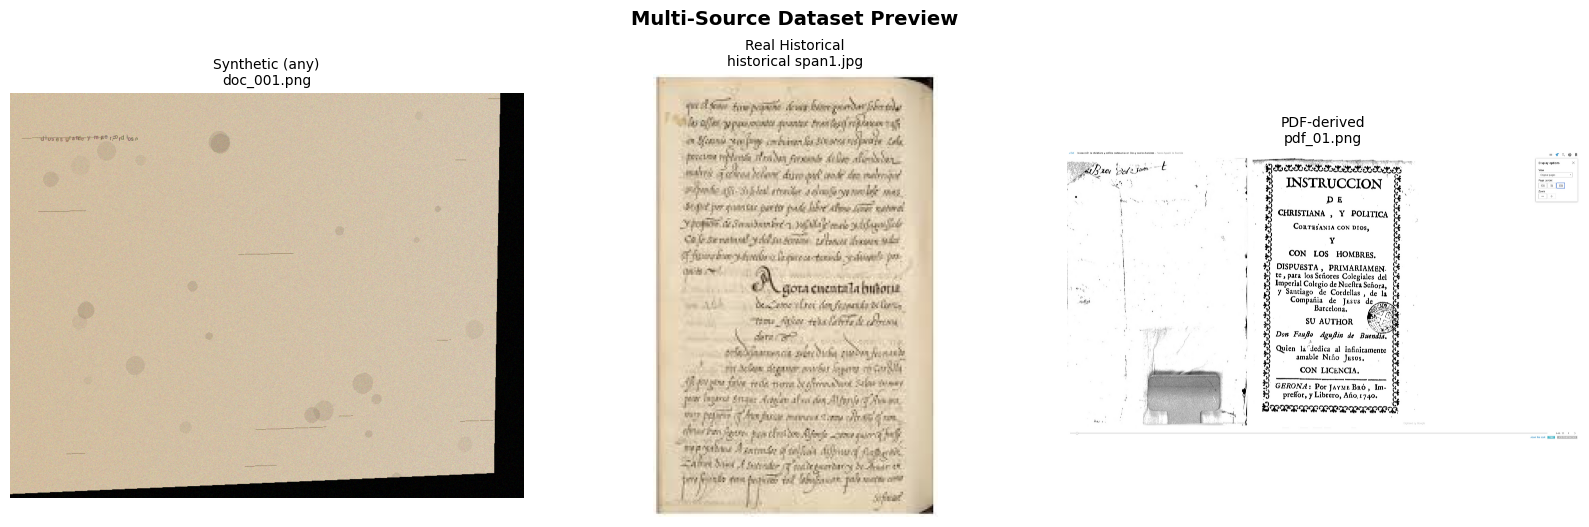


✓ Dataset ready for OCR!



In [31]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import os

# Root folder
image_dir = Path('data/images')

# 🔥 Get ALL images from subfolders
all_images = list(image_dir.rglob('*.png')) + list(image_dir.rglob('*.jpg'))
all_images = sorted(all_images)

print(f"\n{'='*70}")
print(f"DATASET SUMMARY")
print(f"{'='*70}\n")

print(f"Total images: {len(all_images)}")

# 🔥 Categorize based on folder OR filename
synthetic = [f for f in all_images if 'synthetic' in str(f)]
real = [f for f in all_images if 'real' in str(f)]
pdf = [f for f in all_images if 'pdf' in str(f)]

print(f"  • Synthetic:       {len(synthetic)}")
print(f"  • Real historical: {len(real)}")
print(f"  • PDF-derived:     {len(pdf)}")

# ----------------------------
# Visualization (safe version)
# ----------------------------
fig = plt.figure(figsize=(16, 10))

def safe_get(lst):
    return lst[0] if len(lst) > 0 else None

samples = [
    ("Synthetic (any)", safe_get(synthetic)),
    ("Real Historical", safe_get(real)),
    ("PDF-derived", safe_get(pdf)),
]

idx = 1
for category, img_path in samples:
    ax = plt.subplot(2, 3, idx)

    if img_path is not None:
        img = cv2.imread(str(img_path))

        if img is not None:
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            ax.imshow(img_rgb)
        else:
            ax.text(0.5, 0.5, "Failed to load", ha='center')

        ax.set_title(f"{category}\n{img_path.name}", fontsize=10)
    else:
        ax.text(0.5, 0.5, "No image found", ha='center')
        ax.set_title(category)

    ax.axis('off')
    idx += 1

plt.suptitle("Multi-Source Dataset Preview", fontsize=14, fontweight='bold')

# Ensure results folder exists
os.makedirs('results', exist_ok=True)

plt.tight_layout()
plt.savefig('results/01_dataset_preview.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Dataset ready for OCR!\n")

In [33]:
%%writefile /content/drive/MyDrive/OCR_Pipeline_Research/src/preprocess.py
"""
src/preprocess.py
IMAGE PREPROCESSING FOR OCR
"""

import cv2
import numpy as np
from typing import Tuple
import logging

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


class ImagePreprocessor:
    """
    Multi-stage image preprocessing for historical OCR.

    Pipeline:
    1. Grayscale conversion
    2. Denoising (Non-Local Means)
    3. Deskewing (automatic angle detection)
    4. Contrast enhancement (CLAHE)
    5. Resizing (aspect-ratio-preserving)
    """

    def __init__(self, target_height: int = 384, target_width: int = 512):
        """
        Initialize preprocessor.

        Args:
            target_height: Output image height (TrOCR standard)
            target_width: Output image width
        """
        self.target_height = target_height
        self.target_width = target_width
        logger.info(f"Preprocessor initialized: {target_height}×{target_width}")

    def grayscale(self, image: np.ndarray) -> np.ndarray:
        """Convert to grayscale."""
        if len(image.shape) == 2:
            return image
        return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    def denoise(self, image: np.ndarray, strength: int = 10) -> np.ndarray:
        """Remove noise using Non-Local Means Denoising."""
        if len(image.shape) == 2:
            return cv2.fastNlMeansDenoising(
                image,
                h=strength,
                templateWindowSize=7,
                searchWindowSize=21
            )
        return cv2.fastNlMeansDenoisingColored(
            image,
            h=strength,
            templateWindowSize=7,
            searchWindowSize=21
        )

    def deskew(self, image: np.ndarray) -> np.ndarray:
        """Correct rotation/skew in document."""
        if len(image.shape) == 3:
            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        else:
            gray = image.copy()

        _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
        contours, _ = cv2.findContours(
            binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )

        if not contours:
            return image

        largest = max(contours, key=cv2.contourArea)
        angle = cv2.minAreaRect(largest)[2]

        if angle < -45:
            angle += 90

        if abs(angle) < 1.0:
            return image

        h, w = image.shape[:2]
        center = (w // 2, h // 2)
        M = cv2.getRotationMatrix2D(center, angle, 1.0)

        return cv2.warpAffine(
            image, M, (w, h),
            borderMode=cv2.BORDER_REFLECT,
            flags=cv2.INTER_CUBIC
        )

    def enhance_contrast(self, image: np.ndarray) -> np.ndarray:
        """Enhance contrast using CLAHE."""
        if len(image.shape) == 3:
            lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
            l, a, b = cv2.split(lab)
        else:
            l = image.copy()

        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        l_clahe = clahe.apply(l)

        if len(image.shape) == 3:
            lab_clahe = cv2.merge([l_clahe, a, b])
            return cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2BGR)

        return l_clahe

    def resize(self, image: np.ndarray) -> np.ndarray:
        """Resize to standard dimensions while maintaining aspect ratio."""
        h, w = image.shape[:2]
        scale = self.target_height / h
        new_w = int(w * scale)

        resized = cv2.resize(
            image, (new_w, self.target_height),
            interpolation=cv2.INTER_CUBIC
        )

        if new_w < self.target_width:
            pad_left = (self.target_width - new_w) // 2
            pad_right = self.target_width - new_w - pad_left
            resized = cv2.copyMakeBorder(
                resized, 0, 0, pad_left, pad_right,
                cv2.BORDER_CONSTANT, value=255
            )
        elif new_w > self.target_width:
            resized = resized[:, :self.target_width]

        return resized

    def process(self, image_path: str) -> Tuple[np.ndarray, dict]:
        """
        Run complete preprocessing pipeline.

        Args:
            image_path: Path to image file

        Returns:
            (processed_image, intermediate_results)
        """
        image = cv2.imread(image_path)
        if image is None:
            raise FileNotFoundError(f"Cannot read: {image_path}")

        intermediate = {}

        # Step 1: Grayscale
        image = self.grayscale(image)
        intermediate['grayscale'] = image.copy()

        # Step 2: Denoise
        image = self.denoise(image)
        intermediate['denoised'] = image.copy()

        # Step 3: Deskew
        image = self.deskew(image)
        intermediate['deskewed'] = image.copy()

        # Step 4: Enhance contrast
        image = self.enhance_contrast(image)
        intermediate['enhanced'] = image.copy()

        # Step 5: Resize
        image = self.resize(image)
        intermediate['resized'] = image.copy()

        return image, intermediate


# Make available globally
preprocess_module = """
# Use in notebook:
from google.colab import files
import sys
sys.path.insert(0, '/content/drive/My Drive/OCR_Pipeline_Research')

from src.preprocess import ImagePreprocessor

preprocessor = ImagePreprocessor()
processed_img, inter = preprocessor.process('data/images/synthetic_001_clean.png')
"""

print("✓ Preprocessing module created")

Overwriting /content/drive/MyDrive/OCR_Pipeline_Research/src/preprocess.py


In [47]:
%%writefile /content/drive/MyDrive/OCR_Pipeline_Research/src/ocr_engines.py
"""
src/ocr_engines.py
MULTIPLE OCR MODEL SUPPORT
"""
import logging

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)
import torch
from PIL import Image
import cv2
import numpy as np
from typing import Tuple


class TrOCREngine:
    """
    TrOCR: State-of-the-art transformer-based OCR
    Vision Transformer encoder + autoregressive decoder
    """

    def __init__(self, model_name: str = "microsoft/trocr-base-printed"):
        """
        Initialize TrOCR.

        Args:
            model_name: HuggingFace model identifier
        """
        from transformers import TrOCRProcessor, VisionEncoderDecoderModel

        self.device = "cuda" if torch.cuda.is_available() else "cpu"

        logger.info(f"Loading TrOCR on {self.device}...")
        self.processor = TrOCRProcessor.from_pretrained(model_name)
        self.model = VisionEncoderDecoderModel.from_pretrained(model_name)
        self.model = self.model.to(self.device)
        self.model.eval()
        logger.info("✓ TrOCR loaded")

    def recognize(self, image: np.ndarray) -> str:
        """
        Recognize text in image.

        Args:
            image: Preprocessed numpy array

        Returns:
            Recognized text string
        """
        # Convert to PIL Image
        if len(image.shape) == 2:
            pil_image = Image.fromarray(image, mode='L')
        else:
            rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            pil_image = Image.fromarray(rgb_image)

        # Process
        pixel_values = self.processor(
            pil_image, return_tensors="pt"
        ).pixel_values.to(self.device)

        # Generate
        with torch.no_grad():
            generated_ids = self.model.generate(
                pixel_values, max_length=128
            )

        # Decode
        text = self.processor.batch_decode(
            generated_ids, skip_special_tokens=True
        )[0]

        return text.strip()


class TesseractEngine:
    """
    Tesseract: Traditional rule-based OCR (baseline comparison)
    """

    def __init__(self):
        """Initialize Tesseract."""
        import pytesseract
        self.pytesseract = pytesseract
        logger.info("✓ Tesseract ready")

    def recognize(self, image: np.ndarray) -> str:
        """Recognize using Tesseract."""
        if len(image.shape) == 3:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        return self.pytesseract.image_to_string(image).strip()


class EasyOCREngine:

    def __init__(self, languages: list = None):
        import easyocr

        if languages is None:
            languages = ['es']   # ✅ FIXED

        self.reader = easyocr.Reader(
            languages,
            gpu=torch.cuda.is_available()
        )

    def recognize(self, image: np.ndarray) -> str:

        if image is None:
            return ""

        if len(image.shape) == 2:
            image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        results = self.reader.readtext(image_rgb)

        if not results:
            return ""

        return " ".join([text for _, text, _ in results]).strip()


# Factory for easy engine selection
class OCRFactory:
    """Factory for OCR engine instantiation"""

    @staticmethod
    def create(engine_name: str = "trocr", **kwargs):
        """
        Create OCR engine by name.

        Args:
            engine_name: 'trocr', 'tesseract', or 'easyocr'
        """
        if engine_name.lower() == "trocr":
            return TrOCREngine(**kwargs)
        elif engine_name.lower() == "tesseract":
            return TesseractEngine(**kwargs)
        elif engine_name.lower() == "easyocr":
            return EasyOCREngine(**kwargs)
        else:
            raise ValueError(f"Unknown engine: {engine_name}")


print("✓ OCR engines module created")

Overwriting /content/drive/MyDrive/OCR_Pipeline_Research/src/ocr_engines.py


In [49]:
%%writefile /content/drive/MyDrive/OCR_Pipeline_Research/src/metrics.py
"""
src/metrics.py
OCR EVALUATION METRICS
"""
import numpy as np
import editdistance
from typing import Tuple, List, Dict


class Metrics:
    """Compute OCR evaluation metrics"""

    @staticmethod
    def cer(predicted: str, ground_truth: str) -> float:
        """
        Character Error Rate.

        CER = (# character edits) / (# chars in ground truth)
        Range: 0.0 (perfect) to 1.0+ (completely wrong)
        """
        if not ground_truth:
            return 0.0 if not predicted else 1.0

        distance = editdistance.eval(predicted, ground_truth)
        return distance / len(ground_truth)

    @staticmethod
    def wer(predicted: str, ground_truth: str) -> float:
        """
        Word Error Rate.

        WER = (# word edits) / (# words in ground truth)
        """
        pred_words = predicted.split()
        gt_words = ground_truth.split()

        if not gt_words:
            return 0.0 if not pred_words else 1.0

        distance = editdistance.eval(pred_words, gt_words)
        return distance / len(gt_words)

    @staticmethod
    def compute_metrics(
        predicted: str,
        ground_truth: str
    ) -> Dict[str, float]:
        """
        Compute all metrics for a single prediction.
        """
        return {
            'cer': Metrics.cer(predicted, ground_truth),
            'wer': Metrics.wer(predicted, ground_truth),
        }

    @staticmethod
    def batch_metrics(
        predictions: List[str],
        ground_truths: List[str]
    ) -> Dict:
        """
        Compute metrics for multiple predictions.
        """
        if len(predictions) != len(ground_truths):
            raise ValueError("Mismatched lengths")

        cers = []
        wers = []

        for pred, gt in zip(predictions, ground_truths):
            metrics = Metrics.compute_metrics(pred, gt)
            cers.append(metrics['cer'])
            wers.append(metrics['wer'])

        return {
            'avg_cer': np.mean(cers),
            'avg_wer': np.mean(wers),
            'std_cer': np.std(cers),
            'std_wer': np.std(wers),
            'min_cer': min(cers),
            'max_cer': max(cers),
            'cers': cers,
            'wers': wers,
        }


print("✓ Metrics module created")

Overwriting /content/drive/MyDrive/OCR_Pipeline_Research/src/metrics.py


In [36]:
%%writefile /content/drive/MyDrive/OCR_Pipeline_Research/src/vocab_builder.py
import re
from typing import List, Set


class VocabBuilder:
    """Build vocabulary from dataset texts"""

    @staticmethod
    def build_from_texts(texts: List[str], min_freq: int = 1) -> Set[str]:
        freq = {}

        for text in texts:
            words = re.findall(r"\b\w+\b", text.lower())
            for word in words:
                if len(word) <= 1:
                    continue  # skip very small tokens
                freq[word] = freq.get(word, 0) + 1

        vocab = {word for word, count in freq.items() if count >= min_freq}
        return vocab

Overwriting /content/drive/MyDrive/OCR_Pipeline_Research/src/vocab_builder.py


In [50]:
%%writefile /content/drive/MyDrive/OCR_Pipeline_Research/src/corrector.py
import editdistance
import re
from typing import Set


class LexiconCorrector:
    """
    Language-aware dictionary-based error correction
    """

    def __init__(self, vocabulary: Set[str]):
        if not vocabulary:
            raise ValueError("Vocabulary cannot be empty")
        self.vocabulary = vocabulary

    def correct_word(self, word: str, max_distance: int = 2) -> str:
        word_lower = word.lower()

        if word_lower in self.vocabulary:
            return word

        best_match = None
        best_distance = float('inf')

        for vocab_word in self.vocabulary:
            if abs(len(word_lower) - len(vocab_word)) > max_distance:
                continue

            dist = editdistance.eval(word_lower, vocab_word)
            if dist < best_distance:
                best_distance = dist
                best_match = vocab_word

        if best_match and best_distance <= max_distance:
            if word[0].isupper():
                return best_match.capitalize()
            return best_match

        return word

    def correct(self, text: str, max_distance: int = 2) -> str:
        tokens = re.findall(r"\b\w+\b|\W+", text)

        corrected_tokens = []
        for token in tokens:
            if re.match(r"\w+", token):
                corrected_tokens.append(self.correct_word(token, max_distance))
            else:
                corrected_tokens.append(token)

        return "".join(corrected_tokens)

Overwriting /content/drive/MyDrive/OCR_Pipeline_Research/src/corrector.py


In [44]:
import os
openai.api_key = os.environ.get("OPENAI_API_KEY")  # set this in Colab Secrets

In [45]:
from openai import OpenAI

client = OpenAI()

class LLMCorrector:
    def correct(self, text: str) -> str:
        if not text or text.strip() == "":
            return text

        try:
            response = client.chat.completions.create(
                model="gpt-4o-mini",
                messages=[
                    {
                        "role": "system",
                        "content": (
                            "You are an expert in correcting OCR text in Spanish. "
                            "Fix spelling mistakes, restore proper words, and remove noise. "
                            "Do NOT change meaning. Keep output clean and readable."
                        )
                    },
                    {
                        "role": "user",
                        "content": text
                    }
                ],
                temperature=0.2
            )

            return response.choices[0].message.content.strip()

        except Exception as e:
            print("LLM failed:", e)
            return text

In [ ]:
!cat /content/drive/MyDrive/OCR_Pipeline_Research/src/vocab_builder.py

In [48]:
%%writefile /content/drive/MyDrive/OCR_Pipeline_Research/src/pipeline.py
"""
src/pipeline.py
COMPLETE OCR PIPELINE ORCHESTRATION
"""
import matplotlib.pyplot as plt
import logging
import cv2
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)
from pathlib import Path
import numpy as np
from typing import List, Dict
from src.ocr_engines import OCRFactory
from src.corrector import LexiconCorrector
from src.llm_corrector import LLMCorrector
from src.preprocess import ImagePreprocessor
import logging

logger = logging.getLogger(__name__)

class OCRPipeline:
    """
    Complete OCR pipeline with all stages.

    Image → Preprocess → OCR → Lexicon → LLM → Output
    """

    def __init__(
        self,
        ocr_engine: str = "trocr",
        use_lexicon: bool = True,
        use_llm: bool = False,
        vocabulary: set = None
    ):
        """
        Initialize pipeline.

        Args:
            ocr_engine: 'trocr', 'tesseract', or 'easyocr'
            use_lexicon: Apply lexicon-based correction
            use_llm: Apply LLM-based correction
        """
        self.preprocessor = ImagePreprocessor()
        self.ocr_engine = OCRFactory.create(ocr_engine)
        if use_lexicon:
            if vocabulary is None:
                raise ValueError("Vocabulary must be provided when use_lexicon=True")
            self.lexicon_corrector = LexiconCorrector(vocabulary)
        else:
            self.lexicon_corrector = None
        self.llm_corrector = LLMCorrector() if use_llm else None

        logger.info(f"Pipeline initialized with {ocr_engine}")
        logger.info(f"  Lexicon correction: {use_lexicon}")
        logger.info(f"  LLM correction: {use_llm}")

    def process(self, image_path: str) -> Dict[str, str]:
        """
        Process image through complete pipeline.

        Args:
            image_path: Path to image file

        Returns:
            Dict with outputs at each stage
        """
        # Stage 1: Preprocess
        logger.info(f"\nProcessing: {Path(image_path).name}")
        processed_img, _ = cv2.imread(image_path)

        # Stage 2: OCR
        logger.info("  → OCR recognition")
        text_ocr = self.ocr_engine.recognize(processed_img)

        # Stage 3: Lexicon correction
        text_lexicon = text_ocr
        if self.lexicon_corrector:
            logger.info("  → Lexicon correction")
            text_lexicon = self.lexicon_corrector.correct(text_ocr)

        # Stage 4: LLM correction
        text_llm = text_lexicon
        if self.llm_corrector:
            logger.info("  → LLM correction")
            text_llm = self.llm_corrector.correct(text_lexicon)
        plt.imshow(processed_img, cmap='gray')
        plt.title("Processed Image")
        plt.show()
        return {
            'raw': text_ocr,
            'lexicon': text_lexicon,
            'llm': text_llm,
            'final': text_llm,
        }

    def batch_process(
        self,
        image_paths: List[str]
    ) -> List[Dict]:
        """
        Process multiple images.

        Args:
            image_paths: List of image paths

        Returns:
            List of output dicts
        """
        results = []

        for idx, path in enumerate(image_paths, 1):
            logger.info(f"\n[{idx}/{len(image_paths)}]")
            result = self.process(path)
            results.append({
                'filename': Path(path).name,
                **result
            })

        return results


print("✓ Pipeline orchestrator created")

Overwriting /content/drive/MyDrive/OCR_Pipeline_Research/src/pipeline.py


In [52]:
import logging

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)
"""
COMPLETE PIPELINE EVALUATION (COLAB-FIXED VERSION)
"""

import sys
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import logging
import importlib

# ------------------ CONFIG ------------------
BASE_PATH = "/content/drive/MyDrive/OCR_Pipeline_Research"

# Add project path
sys.path.append(BASE_PATH)

# ------------------ IMPORTS ------------------
from src.pipeline import OCRPipeline
from src.metrics import Metrics
from src.vocab_builder import VocabBuilder
from src.ocr_engines import OCRFactory
from src.corrector import LexiconCorrector
from src.llm_corrector import LLMCorrector
from src.preprocess import ImagePreprocessor
# Reload (important in Colab)
import logging

logging.basicConfig(level=logging.INFO, format='%(message)s')
logger = logging.getLogger(__name__)


# ------------------ LOAD GROUND TRUTH ------------------
def load_ground_truth(gt_file):
    gt = {}

    with open(gt_file, encoding="utf-8") as f:
        for line in f:
            if line.strip() and not line.startswith('#'):
                parts = line.strip().split('\t', 1)
                if len(parts) == 2:
                    gt[parts[0].strip()] = parts[1].strip()

    return gt


# ------------------ MAIN FUNCTION ------------------
def run_complete_evaluation():
    print(f"\n{'='*80}")
    print(" " * 20 + "COMPLETE OCR PIPELINE EVALUATION")
    print(f"{'='*80}\n")

    # -------- [1] Load images --------
    print("[1/5] Loading dataset...")
    image_dir = Path(f"{BASE_PATH}/data/images")

    images = [
        p for p in image_dir.rglob('*')
        if p.is_file() and p.suffix.lower() in ['.png', '.jpg', '.jpeg']
    ]

    print(f"Found {len(images)} images")

    if len(images) == 0:
        print("❌ No images found!")
        print("DEBUG:")
        print("All files:")
        for p in image_dir.rglob('*'):
            print(" -", p)
        return None

    # -------- [2] Load ground truth --------
    print("[2/5] Loading ground truth...")
    gt_path = f"{BASE_PATH}/data/ground_truth_full.txt"

    print("  GT file exists:", Path(gt_path).exists())

    gt = load_ground_truth(gt_path)
    print(f"  Loaded {len(gt)} annotations")

    # -------- [3] Build vocabulary --------
    print("[3/5] Building vocabulary...")

# Step 1: build vocab
    vocab = VocabBuilder.build_from_texts(list(gt.values()))

    # Step 2: filter vocab
    vocab = {
        word for word in vocab
        if len(word) > 2
    }

    print(f"  Vocabulary size: {len(vocab)}")

    # -------- [4] Initialize pipeline --------
    print("[4/5] Initializing pipeline...")

    pipeline = OCRPipeline(
        ocr_engine="easyocr",   # better for Spanish
        use_lexicon=True,
        use_llm=True,
        vocabulary=vocab
    )

    # -------- [5] Run pipeline --------
    print("[5/5] Running OCR pipeline...\n")

    results = []

    for idx, img_path in enumerate(images, 1):
        print(f"[{idx}/{len(images)}] {img_path.name}")

        rel_path = str(img_path).replace(BASE_PATH + "/", "")

        if rel_path not in gt:
            print("  ⚠ No ground truth, skipping")
            continue

        try:
            pipeline_result = pipeline.process(str(img_path))
        except Exception as e:
            print(f"  ❌ Error: {e}")
            continue

        gt_text = gt[rel_path]
        print("\n--- DEBUG ---")
        print("GT :", gt_text)
        print("RAW:", pipeline_result['raw'])
        print("LEX:", pipeline_result['lexicon'])
        print("LLM:", pipeline_result['llm'])
        print("--------------\n")

        for stage in ['raw', 'lexicon', 'llm']:
            text = pipeline_result[stage]
            metrics = Metrics.compute_metrics(text, gt_text)

            results.append({
                'filename': img_path.name,
                'stage': stage,
                'text': text,
                'ground_truth': gt_text,
                'cer': metrics['cer'],
                'wer': metrics['wer'],
            })

            print(f"   {stage:>8} → CER: {metrics['cer']:.3f}")

    # -------- RESULTS --------
    df = pd.DataFrame(results)

    if df.empty:
        print("❌ No results generated!")
        return None

    print(f"\n{'='*80}")
    print("RESULTS BY STAGE")
    print(f"{'='*80}\n")

    summary = df.groupby('stage')[['cer', 'wer']].mean()
    print(summary)

    print(f"\n{'='*80}")
    print("BEST RESULTS (FINAL OUTPUT)")
    print(f"{'='*80}\n")

    final_df = df[df['stage'] == 'llm'][['filename', 'cer', 'wer']]
    print(final_df.sort_values('cer').to_string(index=False))

    # -------- PLOT --------
    print("\n📊 Plotting results...")

    df.groupby('stage')['cer'].mean().plot(kind='bar', title="CER by Stage")
    plt.show()

    return df


# ------------------ RUN ------------------
evaluation_df = run_complete_evaluation()


=== TROCR ===


Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-printed
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


AttributeError: type object 'Metrics' has no attribute 'compute'